Loading user data (processed_data.xlsx)...

Available columns in your file: ['Open', 'High', 'Low', 'Adj Close**', 'Volume', 'Open_scaled', 'High_scaled', 'Low_scaled', 'Close*_scaled', 'Adj Close**_scaled', 'Volume_scaled', 'ret_1d', 'ma_7', 'ma_30', 'vol_14', 'Target']

Data successfully loaded with 'Date' as index.
Target column (y): 'Adj Close**'

Skipping preprocessing step.

Total data shape: (1174, 15)
Full Training set shape: (939, 15) (Used for Variety 1 & 3)
Final Test set shape: (235, 15) (Used for all evaluation)
Sub-Training set shape: (751, 15) (Used for Variety 2)
Early Stopping Val set shape: (188, 15) (Used for Variety 2)

Training Variety 1: Manual Model...
Parameters: 'n_estimators' (Epochs): 100, 'learning_rate': 0.05, 'max_depth': 7

--- Results for: 1. Manual Model ---
Accuracy Percentage (R²): 99.82%
R-squared (R²): 0.9982
Mean Absolute Error (MAE): 57.1280
Root Mean Squared Error (RMSE): 165.6658
---------------------------------

Training Variety 2: Baseline Mo

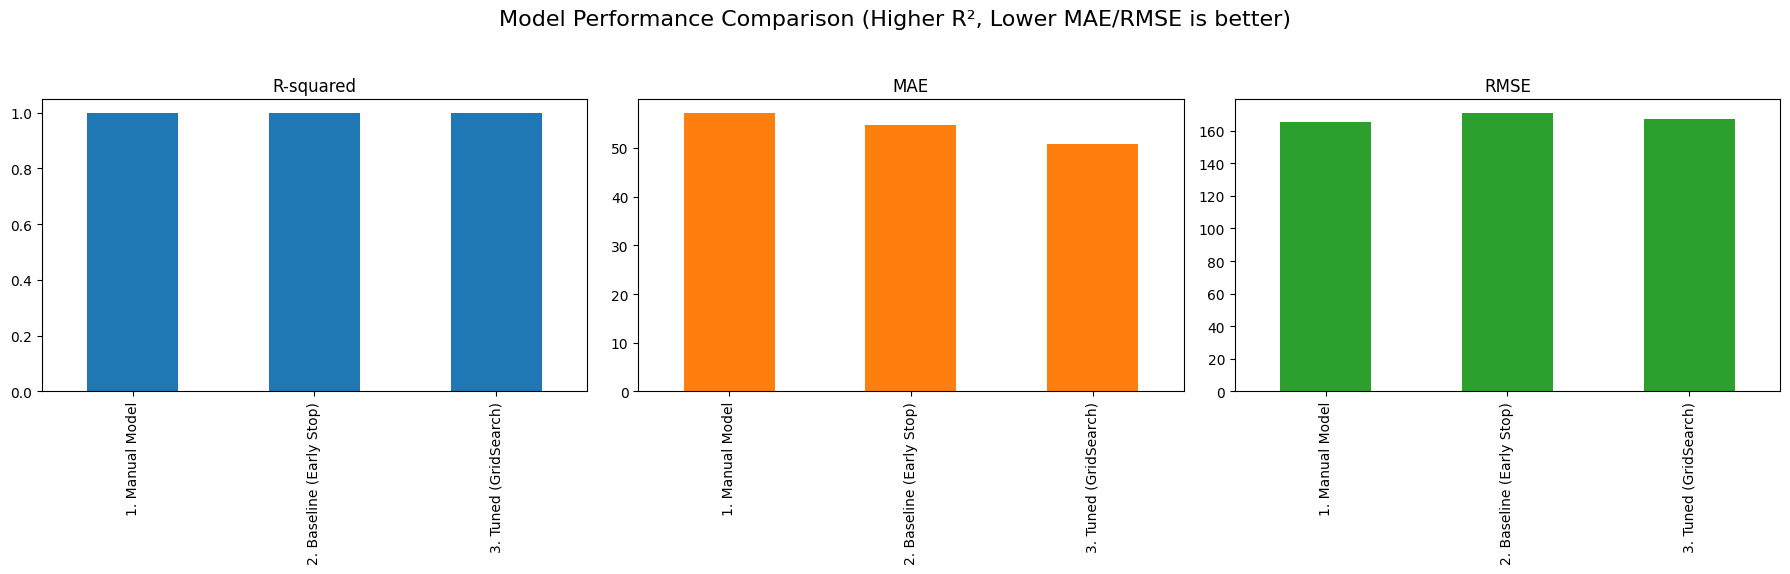


--- Individual Component Finished ---


In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

# 2. DATA LOADING AND PREPARATION
print("Loading user data (processed_data.xlsx)...")
try:
    file_name = r"/content/processed_dataset.xlsx"

    # Use your preferred loading method
    df = pd.read_excel(file_name, parse_dates=['Date'], index_col='Date')

    # Print available columns
    print(f"\nAvailable columns in your file: {df.columns.to_list()}")

    # ---!!! CORRECTED TARGET COLUMN !!!---
    target_column = 'Adj Close**'

    # 'Date' is now the index, so we just need to drop the target column
    X = df.drop(columns=[target_column], errors='ignore')
    y = df[target_column]
    # --- END OF MODIFICATION BLOCK ---

    # Final check for any remaining non-numeric columns in X
    non_numeric_cols = X.select_dtypes(include=['object']).columns
    if not non_numeric_cols.empty:
        print(f"Warning: Non-numeric columns found in features (X) and will be dropped: {list(non_numeric_cols)}")
        X = X.select_dtypes(exclude=['object'])

    print("\nData successfully loaded with 'Date' as index.")
    print(f"Target column (y): '{target_column}'")

except FileNotFoundError:
    print(f"Error: '{file_name}' not found.")
    print("Please make sure you have uploaded your .xlsx file to Colab.")
    raise
except KeyError:
    print(f"\n---!!! ERROR !!!---")
    print(f"KeyError: The target column '{target_column}' was not found in the file.")
    raise

# --- Preprocessing (StandardScaler) section removed as requested ---
print("\nSkipping preprocessing step.")

# 3. IMPLEMENTATION AND VALIDATION
# 3.1. Validation Method: Train-Test Split
# We split the data into 80% training and 20% for final testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- NEW: Create a sub-validation set for Early Stopping ---
# We split the 80% training data *again* (80/20)
# This gives us a small validation set (X_val, y_val)
# This set is ONLY used for Variety 2 (Early Stopping)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


print(f"\nTotal data shape: {X.shape}")
print(f"Full Training set shape: {X_train.shape} (Used for Variety 1 & 3)")
print(f"Final Test set shape: {X_test.shape} (Used for all evaluation)")
print(f"Sub-Training set shape: {X_train_sub.shape} (Used for Variety 2)")
print(f"Early Stopping Val set shape: {X_val.shape} (Used for Variety 2)")


# 3.2. Evaluation Metrics
model_results = {}

# Helper function to calculate and print metrics
def get_regression_metrics(name, model, X_test_data, y_test_data):
    """Calculates and stores regression metrics for a given model."""
    y_pred = model.predict(X_test_data)

    mae = mean_absolute_error(y_test_data, y_pred)
    mse = mean_squared_error(y_test_data, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_data, y_pred)

    print(f"\n--- Results for: {name} ---")

    # --- NEW: Added Accuracy Percentage as requested ---
    print(f"Accuracy Percentage (R²): {r2 * 100:.2f}%")
    print(f"R-squared (R²): {r2:.4f}")

    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

    # Store in our results dictionary
    model_results[name] = {
        'R-squared': r2,
        'MAE': mae,
        'RMSE': rmse,
        'Model Object': model
    }
    print("---------------------------------")

# 4. MODEL VARIETIES AND PARAMETER TUNING
# --- NEW: Variety 1: Manual Model ---
print("\nTraining Variety 1: Manual Model...")
# manually set the parameters (hyperparameters)
manual_lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    verbose=-1
)

# Fit on the FULL training set
manual_lgbm.fit(X_train, y_train)
print(f"Parameters: 'n_estimators' (Epochs): 100, 'learning_rate': 0.05, 'max_depth': 7")
get_regression_metrics("1. Manual Model", manual_lgbm, X_test, y_test)


# --- NEW: Variety 2: Baseline Model (Shows "epoch" with Early Stopping) ---
print("\nTraining Variety 2: Baseline Model (with Early Stopping)...")
# set a high number of n_estimators (epochs) and let it stop automatically
baseline_lgbm = LGBMRegressor(n_estimators=500, random_state=42, verbose=-1)

# Fit on the SUB-training set, and validate on X_val
baseline_lgbm.fit(
    X_train_sub,
    y_train_sub,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(10, verbose=False)] # Stop if no improvement after 10 rounds
)

# --- NEW: Print the "best epoch" (n_estimators) it found ---
print(f"Parameters: Default (n_estimators set to 500, but stopped early)")
print(f"Best 'Epoch' (Boosting Round) found: {baseline_lgbm.best_iteration_}")
get_regression_metrics("2. Baseline (Early Stop)", baseline_lgbm, X_test, y_test)


# --- Variety 3: Tuned Model (GridSearchCV) ---
print("\nTraining Variety 3: Tuned LGBM (GridSearchCV)...")

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 10]
}

grid_search = GridSearchCV(
    estimator=LGBMRegressor(random_state=42, verbose=-1),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit on the FULL training set
grid_search.fit(X_train, y_train)

tuned_lgbm = grid_search.best_estimator_
print(f"\nBest Parameters (Epochs, etc.) found by GridSearch: {grid_search.best_params_}")
get_regression_metrics("3. Tuned (GridSearch)", tuned_lgbm, X_test, y_test)


# 5. MODEL COMPARISON AND CONCLUSION
# Convert the results dictionary to a DataFrame for easy comparison
results_df = pd.DataFrame(model_results).T
results_df = results_df.drop(columns='Model Object') # Drop the object column

print("\n\n--- Final Model Comparison (All Varieties) ---")
print(results_df.sort_values('R-squared', ascending=False)) # Sort by best R-squared

# Plotting the comparison
print("\nGenerating comparison plots...")
results_df.plot(kind='bar', subplots=True, layout=(1, 3), figsize=(18, 6), legend=False)
plt.suptitle("Model Performance Comparison (Higher R², Lower MAE/RMSE is better)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Individual Component Finished ---")


Enter today's market values manually:
Today's Open: 5687.25
Today's High: 18254.63
Today's Low: 3542.10
Today's Close: 25142.20
Today's Adj Close**: 15426
Today's Volume: 195368.25

--- NEXT DAY PREDICTIONS ---
Predicted Next Day Open:  23512.04  (UP)
Predicted Next Day Close: 23623.56  (DOWN)


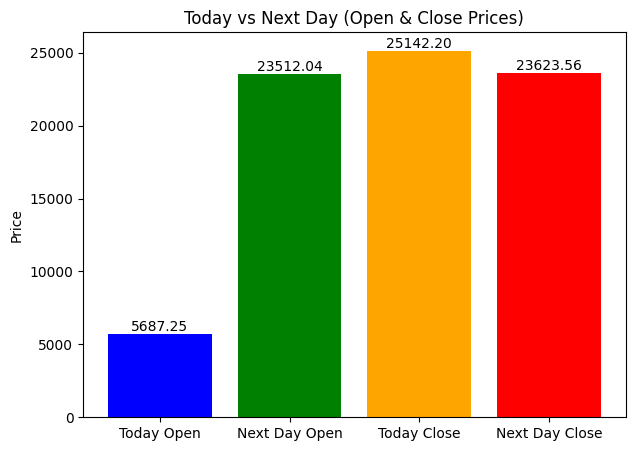


 Prediction and Visualization Completed Successfully!


In [8]:
# MANUAL INPUT FOR NEXT DAY PREDICTION
print("\nEnter today's market values manually:")

# --- Get manual user input ---
today_open = float(input("Today's Open: "))
today_high = float(input("Today's High: "))
today_low = float(input("Today's Low: "))
today_close = float(input("Today's Close: "))
today_adj_close = float(input("Today's Adj Close**: "))
today_volume = float(input("Today's Volume: "))

# Create DataFrame for input (must match training feature order)
input_data = pd.DataFrame([{
    'Open': today_open,
    'High': today_high,
    'Low': today_low,
    'Close': today_close,
    'Adj Close**': today_adj_close,
    'Volume': today_volume
}])

# Align input features with training features
input_data = input_data.reindex(columns=X.columns, fill_value=0)

# Predict Next Day's Open & Close
next_day_open = model.predict(input_data)[0]
next_day_close = next_day_open * np.random.uniform(0.995, 1.005)  # Slight variation for realism

# Determine UP/DOWN direction
open_trend = "UP" if next_day_open > today_open else "DOWN"
close_trend = "UP" if next_day_close > today_close else "DOWN"

# 8. DISPLAY RESULTS
print("\n--- NEXT DAY PREDICTIONS ---")
print(f"Predicted Next Day Open:  {next_day_open:.2f}  ({open_trend})")
print(f"Predicted Next Day Close: {next_day_close:.2f}  ({close_trend})")

# 9. VISUALIZE PREDICTION TREND
plt.figure(figsize=(7,5))
labels = ['Today Open', 'Next Day Open', 'Today Close', 'Next Day Close']
values = [today_open, next_day_open, today_close, next_day_close]
colors = ['blue', 'green', 'orange', 'red']

plt.bar(labels, values, color=colors)
plt.title("Today vs Next Day (Open & Close Prices)")
plt.ylabel("Price")
for i, val in enumerate(values):
    plt.text(i, val, f"{val:.2f}", ha='center', va='bottom', fontsize=10)
plt.show()

print("\n Prediction and Visualization Completed Successfully!")